In [1]:
import os
import numpy as np
import pickle
from statsmodels.stats.multitest import fdrcorrection
import scipy.stats as stats
import scipy.io as sio
import matplotlib.pyplot as plt
from nilearn.image import new_img_like
import pandas as pd
import nibabel as nib
import csv
from nilearn import plotting
from nilearn.image import resample_img
from nilearn.image import math_img
from rsatoolbox.inference import eval_fixed
from rsatoolbox.model import ModelFixed
from glob import glob
import nilearn.image as nlimg
from rsatoolbox.util.searchlight import get_volume_searchlight, get_searchlight_RDMs, evaluate_models_searchlight

from scipy.stats import spearmanr
from tqdm import tqdm
# from rsatoolbox.data.dataset import Dataset
# from rsatoolbox.rdm.calc import calc_rdm
# from rsatoolbox.rdm import RDMs
import seaborn as sns
from sklearn.metrics import pairwise_distances
import copy

In [2]:
def upper_tri(RDM):
    """upper_tri returns the upper triangular index of an RDM

    Args:
        RDM 2Darray: squareform RDM

    Returns:
        1D array: upper triangular vector of the RDM
    """
    # returns the upper triangle
    m = RDM.shape[0]
    r, c = np.triu_indices(m, 1)
    return RDM[r, c]

In [3]:
import matplotlib.colors
def RDMcolormapObject(direction=1):
    """
    Returns a matplotlib color map object for RSA and brain plotting
    """
    if direction == 0:
        cs = ['yellow', 'red', 'gray', 'turquoise', 'blue']
    elif direction == 1:
        cs = ['blue', 'turquoise', 'gray', 'red', 'yellow']
    else:
        raise ValueError('Direction needs to be 0 or 1')
    cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", cs)
    return cmap

In [4]:
tmp_image_path = '../IAPS_fMRI_RSA/fMRI_singletrial_betas/nifti/Nt1.img'
# load one image to get the dimensions and make the mask

tmp_img = nib.load(tmp_image_path)

## Create mask for RDMs

### Using subject fMRI data to create mask

    Avoid using subject data that included eyeball voxels. Subjects 4, 5, 10, 11, 15, 16, and 17 fMRI data do not contain eyeball voxels. 

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_44940\3353029201.py:26: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  mask_3d = new_img_like(tmp_img, mask)
c:\Users\yujunchen\AppData\Local\miniconda3\envs\neuro_161\Lib\site-packages\numpy\_core\fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_44940\3353029201.py:27: UserWarning: Casting data from int32 to float32
  view = plotting.view_img(mask_3d)
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_44940\3353029201.py:27: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might con


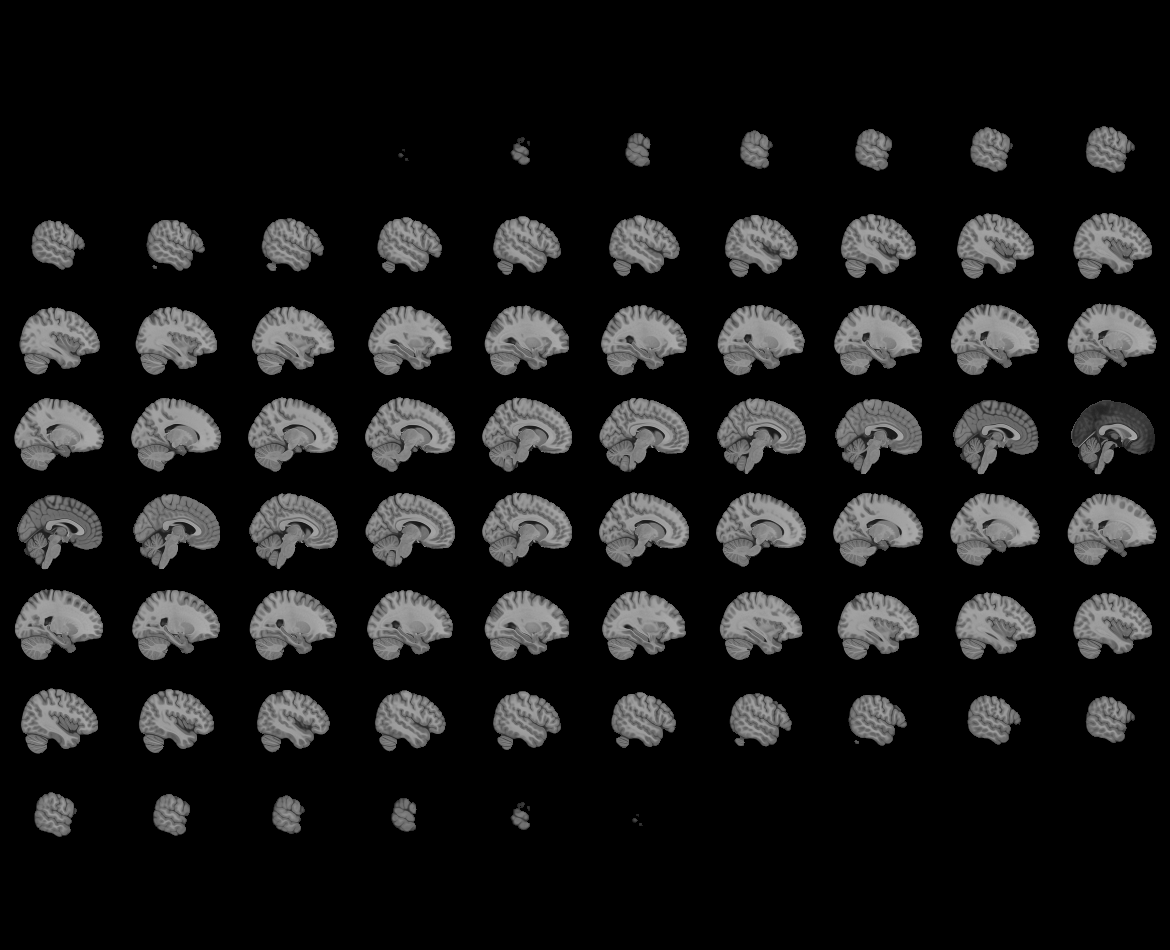
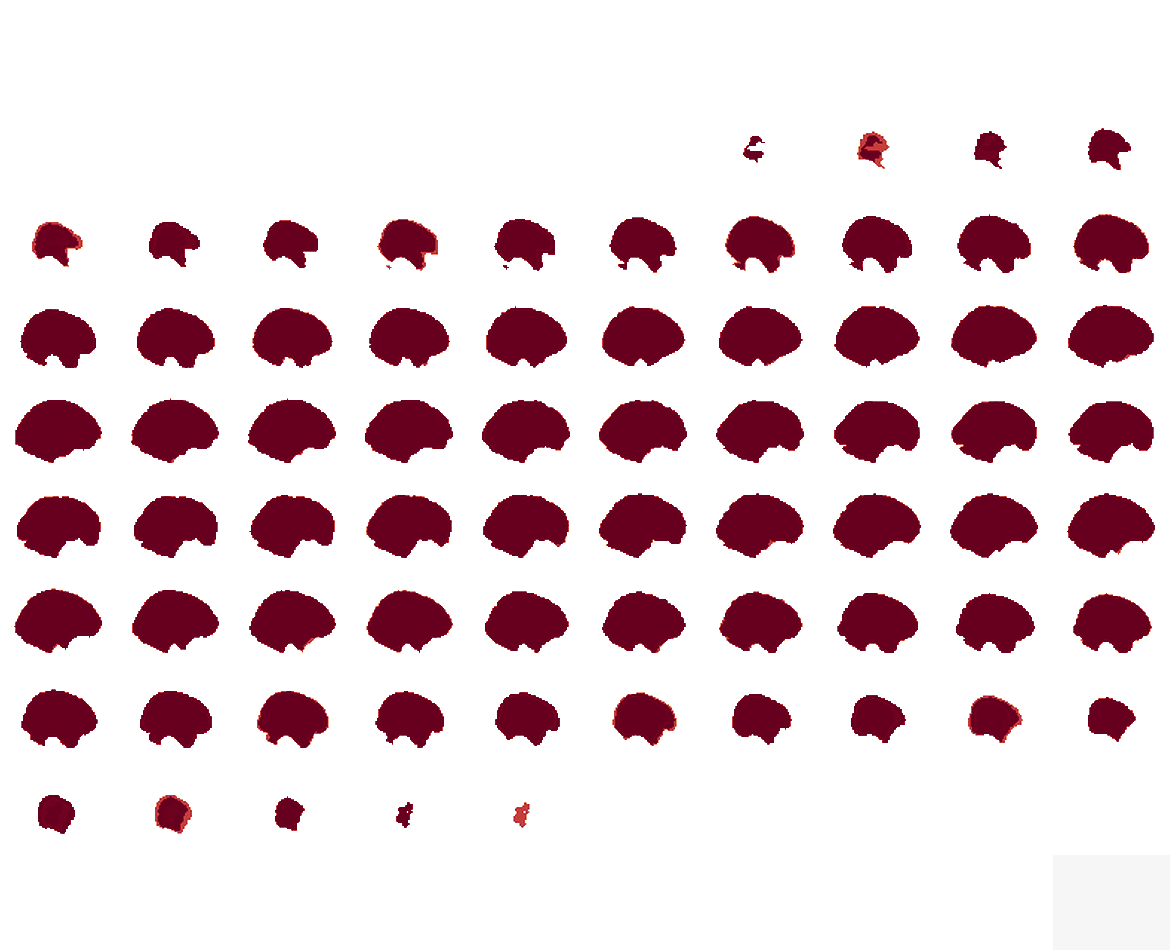

In [5]:
stimuli = ['Pl','Nt','Up']
no_eyeballvoxel_subjects = [4,5,10,11,15,16,17]

sub_mask_list = []
for s, sub in enumerate(no_eyeballvoxel_subjects):

    mask_list = []
    for i, stim in enumerate(stimuli):
        image_path = '../IAPS_fMRI_RSA/fMRI_singletrial_betas/{}{}.mat'.format(stim,sub-1)
        # load one image to get the dimensions and make the mask
        image_file = sio.loadmat(image_path)
        mask_file = image_file['{}'.format(stim)] #(153594, 100)
        mask_list.append(mask_file)

    allmask = np.hstack(mask_list)
    mask_sum = np.sum(allmask, axis = 1)
    sub_mask_list.append(mask_sum)

allsub_mask = np.vstack(sub_mask_list)
allsub_mask_sum = np.sum(allsub_mask, axis = 0)
mask_flat = (~np.isnan(allsub_mask_sum)).astype(int)
x, y, z = 53,63,46
mask_reshape = mask_flat.reshape(z, y, x)
mask = np.moveaxis(mask_reshape, [0,1,2], [2,1,0])

mask_3d = new_img_like(tmp_img, mask)
view = plotting.view_img(mask_3d)
view

In [ ]:
# Export mask
np.save("./mask.npy", mask)

In [6]:
# Import mask
mask = np.load("./mask.npy")

### Create searchlight centers and neighbours

In [7]:
centers, neighbors = get_volume_searchlight(mask, radius=5, threshold=0.5)

Finding searchlights...: 100%|██████████| 59159/59159 [00:06<00:00, 9169.69it/s]


Found 56949 searchlights


In [8]:
n_voxels_per_center = [len(n) for n in neighbors]

# Basic stats
import numpy as np
print("Min voxels per sphere:", np.min(n_voxels_per_center))
print("Max voxels per sphere:", np.max(n_voxels_per_center))
print("Mean voxels per sphere:", np.mean(n_voxels_per_center))

Min voxels per sphere: 277
Max voxels per sphere: 485
Mean voxels per sphere: 483.81609861454984


In [48]:
# ...existing code...

import numpy as np
from rsatoolbox.util.searchlight import get_volume_searchlight

min_radius = 2
max_radius = 6  # inclusive

print("radius | overlap | total_voxels | overlap_ratio")
print("-----------------------------------------------")

for radius in range(min_radius, max_radius + 1):
    centers, neighbors = get_volume_searchlight(mask, radius=radius, threshold=0.5)
    n_spheres = len(neighbors)
    rng = np.random.default_rng()
    center_idx = rng.integers(0, n_spheres)
    adjacent_idx = (center_idx + 1) % n_spheres

    voxels_center = set(neighbors[center_idx])
    voxels_adjacent = set(neighbors[adjacent_idx])

    overlap = len(voxels_center.intersection(voxels_adjacent))
    total_voxels = len(voxels_center.union(voxels_adjacent))
    overlap_ratio = overlap / total_voxels if total_voxels > 0 else 0

    print(f"{radius:>6} | {overlap:>7} | {total_voxels:>12} | {overlap_ratio:.3f}")

# ...existing code...

radius | overlap | total_voxels | overlap_ratio
-----------------------------------------------


Finding searchlights...: 100%|██████████| 59159/59159 [00:06<00:00, 8620.89it/s] 


Found 58792 searchlights
     2 |      18 |           36 | 0.500


Finding searchlights...: 100%|██████████| 59159/59159 [00:06<00:00, 8831.90it/s] 


Found 58231 searchlights
     3 |      68 |          118 | 0.576


Finding searchlights...: 100%|██████████| 59159/59159 [00:04<00:00, 13737.40it/s]


Found 57550 searchlights
     4 |     206 |          296 | 0.696


Finding searchlights...: 100%|██████████| 59159/59159 [00:10<00:00, 5801.65it/s]


Found 56949 searchlights
     5 |     416 |          554 | 0.751


Finding searchlights...: 100%|██████████| 59159/59159 [00:13<00:00, 4304.45it/s]


Found 56251 searchlights
     6 |     786 |         1004 | 0.783


## Load fMRI data

### Stimuli

In [9]:
stim_file = pd.read_csv('../IAPS_fMRI_RSA/fmri_conditions_trial_ordered.csv')
stim_Nt = stim_file[0:100]
stim_Pl = stim_file[100:200].reset_index()
stim_Up = stim_file[200:300].reset_index()

In [5]:
stim_Up

,index,trial_id,iaps_id,run,type,stim_order,category,Mean_Valence,Mean_Arousal
0,200,4,3030,1,Up,1,mutil/disgust,1.91,6.76
1,201,5,3051,1,Up,2,mutil/disgust,2.30,5.62
2,202,11,1120,1,Up,3,attack,3.79,6.93
3,203,12,6550,1,Up,4,attack,2.73,7.09
4,204,13,3150,1,Up,5,mutil/disgust,2.26,6.55
...,...,...,...,...,...,...,...,...,...
95,295,295,6230,5,Up,15,attack,2.37,7.35
96,296,297,9571,5,Up,16,mutil/disgust,1.96,5.64
97,297,298,3069,5,Up,9,mutil/disgust,1.70,7.03
98,298,299,1114,5,Up,8,attack,4.03,6.33


In [10]:
stim_Nt_id = pd.DataFrame(stim_Nt[['stim_order']]).T
stim_Nt_id.shape
stim_Pl_id = pd.DataFrame(stim_Pl[['stim_order']]).T
stim_Pl_id.shape
stim_Up_id = pd.DataFrame(stim_Up[['stim_order']]).T
stim_Up_id.shape
print("Netrual    Type: {} Shape/Length: {}".format(type(stim_Nt_id), stim_Nt_id.shape))
print("Pleasant   Type: {} Shape/Length: {}".format(type(stim_Pl_id), stim_Pl_id.shape))
print("Unpleasant Type: {} Shape/Length: {}".format(type(stim_Up_id), stim_Up_id.shape))

Netrual    Type: <class 'pandas.core.frame.DataFrame'> Shape/Length: (1, 100)
Pleasant   Type: <class 'pandas.core.frame.DataFrame'> Shape/Length: (1, 100)
Unpleasant Type: <class 'pandas.core.frame.DataFrame'> Shape/Length: (1, 100)


In [7]:
stim_Nt_id

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
stim_order,1,2,3,4,5,6,7,8,9,10,...,10,14,6,8,11,19,4,12,2,1


In [11]:
allsub_avg = []

subjects = 20
for i in range(subjects):
    sub_avg = []
    #Pleasant
    mat_name_Pl = '../IAPS_fMRI_RSA/fMRI_singletrial_betas/Pl{}.mat'.format(i+1)
    mat_file_Pl = sio.loadmat(mat_name_Pl)
    data_Pl = mat_file_Pl['Pl'] #(153594, 100)
    data_Pl_reshape = data_Pl.reshape(46, 63, 53, 100)
    data_Pl_reorder = np.moveaxis(data_Pl_reshape, [0,1,2,3], [2,1,0,3])
    data_Pl_reorder_flat = np.reshape(data_Pl_reorder, (153594,100))
    data_Pl_df = pd.DataFrame(data_Pl_reorder_flat) #(153594, 100)
    Pl_df = pd.concat([stim_Pl_id, data_Pl_df]) #(153595,100)
    Pl_df = Pl_df.T
    Pl_df_gr = Pl_df.groupby('stim_order').mean() #(20, 153594)
    Pl_df_gr = Pl_df_gr.reset_index(drop=True) #(20, 153594) 

    #Neutral
    mat_name_Nt = '../IAPS_fMRI_RSA/fMRI_singletrial_betas/Nt{}.mat'.format(i+1)
    mat_file_Nt = sio.loadmat(mat_name_Nt)
    data_Nt = mat_file_Nt['Nt'] #(153594, 100)
    data_Nt_reshape = data_Nt.reshape(46, 63, 53, 100)
    data_Nt_reorder = np.moveaxis(data_Nt_reshape, [0,1,2,3], [2,1,0,3])
    data_Nt_reorder_flat = np.reshape(data_Nt_reorder, (153594,100))
    data_Nt_df = pd.DataFrame(data_Nt_reorder_flat) #(153594, 100)
    Nt_df = pd.concat([stim_Nt_id,data_Nt_df]) #(153595,100)
    Nt_df = Nt_df.T
    Nt_df_gr = Nt_df.groupby('stim_order').mean() #(20, 153594)
    Nt_df_gr = Nt_df_gr.reset_index(drop=True) #(20, 153594) 


    #Unpleasant
    mat_name_Up = '../IAPS_fMRI_RSA/fMRI_singletrial_betas/Up{}.mat'.format(i+1)
    mat_file_Up = sio.loadmat(mat_name_Up)
    data_Up = mat_file_Up['Up'] #(153594, 100)
    data_Up_reshape = data_Up.reshape(46, 63, 53, 100)
    data_Up_reorder = np.moveaxis(data_Up_reshape, [0,1,2,3], [2,1,0,3])
    data_Up_reorder_flat = np.reshape(data_Up_reorder, (153594,100))
    data_Up_df = pd.DataFrame(data_Up_reorder_flat) #(153594, 100)
    Up_df = pd.concat([stim_Up_id, data_Up_df]) #(153595,100)
    Up_df = Up_df.T
    Up_df_gr = Up_df.groupby('stim_order').mean() #(20, 153594)
    Up_df_gr = Up_df_gr.reset_index(drop=True) #(20, 153594) 

    sub_df = pd.concat([Pl_df_gr, Nt_df_gr, Up_df_gr])
    allsub_avg.append(sub_df)

Output file

In [21]:
np.save("allsub_avg.pyc" , allsub_avg)

Input file

In [20]:
allsub_avg = np.load("allsub_avg.npy", allow_pickle=True)

In [13]:
allsub_avg.shape

(20, 60, 153594)

### Export pre-processed neural data

In [30]:
# dbfile= open('./outputs/20sub_fmri_rdm', 'ab')
# pickle.dump(allsub_avg, dbfile)                     
# dbfile.close()

### Plot one stimulus image out of the 60 images 

c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\_utils\niimg.py:63: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  warn(
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



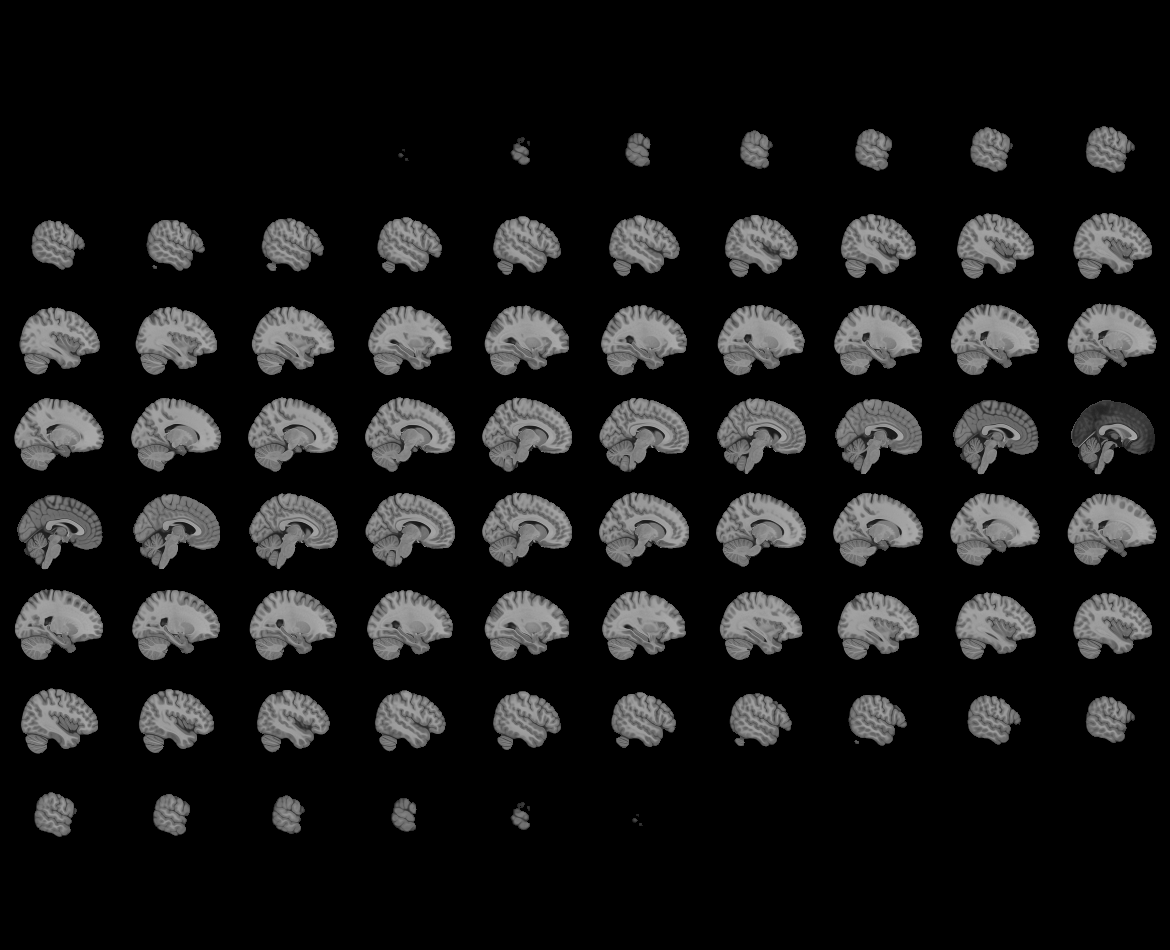
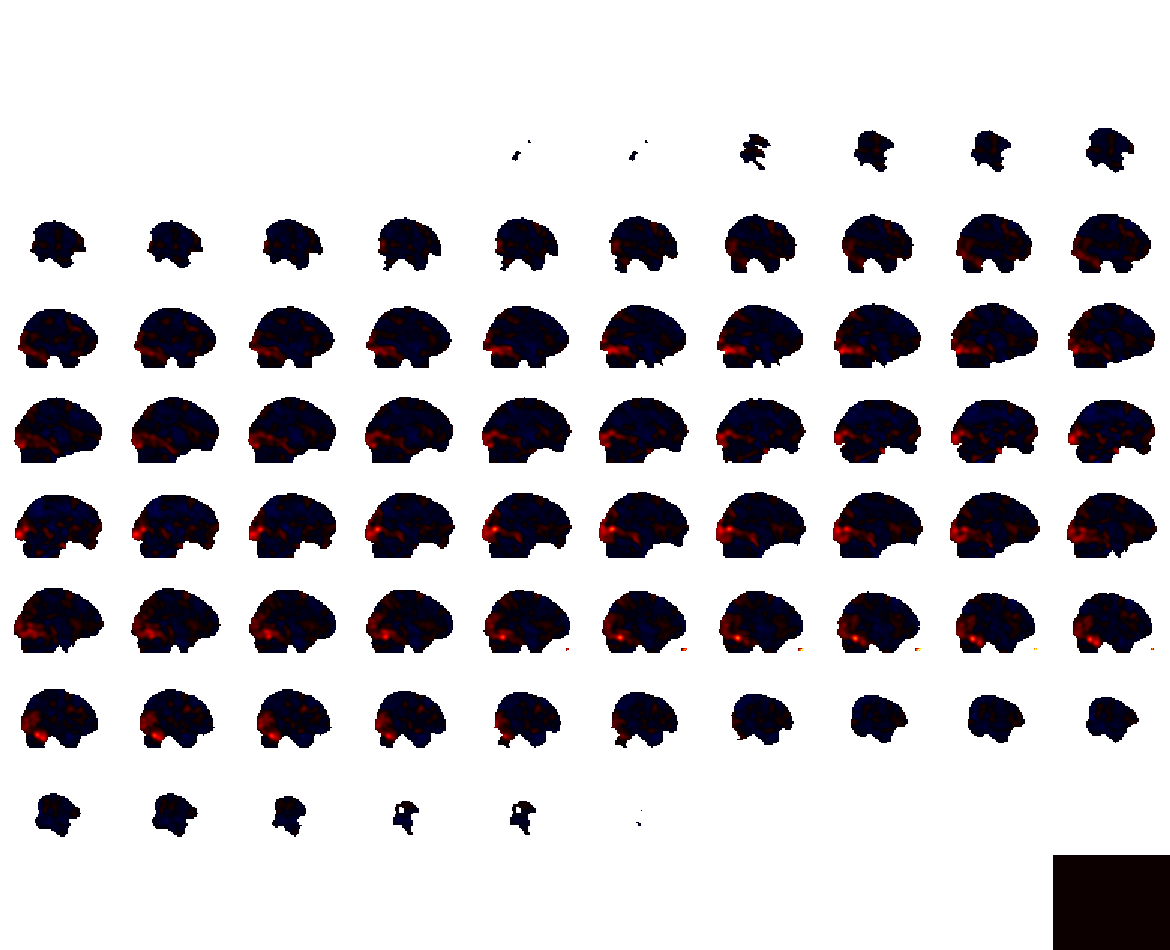

In [19]:
plot_slice = np.array(allsub_avg[10])[1,:]
plot_slice_3d = plot_slice.reshape(53, 63, 46)
plot_neural_rdm_cont1 = new_img_like(tmp_img, plot_slice_3d)
view = plotting.view_img(plot_neural_rdm_cont1)
view

## Load Behavioral RDMs

### Euclidean based behavioral RDM

In [15]:
rdm_emonet = pd.read_csv("./RDM/rdm_EmoNet.csv", index_col=0)
rdm_emonet = np.array(rdm_emonet)

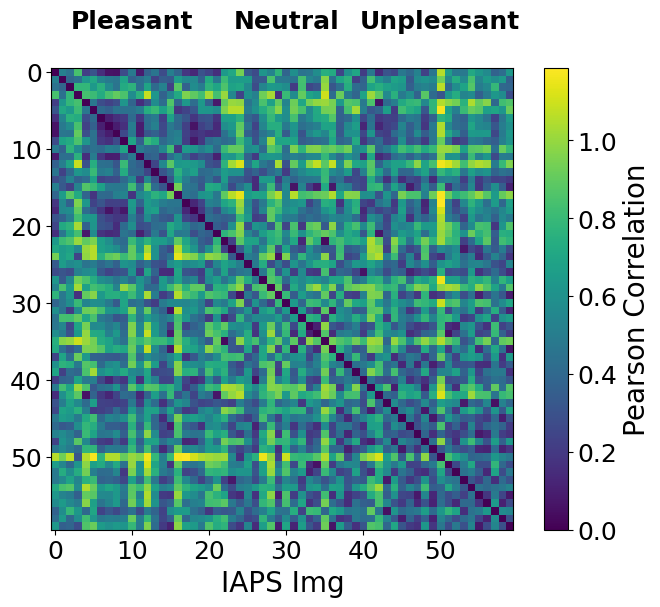

In [16]:
import matplotlib.pyplot as plt

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size if needed

# Show image
shw = ax.imshow(rdm_emonet)

# Add colorbar
bar = plt.colorbar(shw)

# Increase font size
plt.xlabel('IAPS Img', fontsize=20)  # Larger x-axis label
# plt.ylabel('IAPS Img', fontsize=20)  # Larger y-axis label
bar.set_label('Pearson Correlation', fontsize=20)  # Larger colorbar label

# Increase tick label size
ax.tick_params(axis='both', labelsize=18)  # Both x and y ticks
bar.ax.tick_params(labelsize=18)  # Colorbar tick labels

# Define category labels and their positions
category_labels = ['Pleasant', 'Neutral', 'Unpleasant']
tick_positions = [10, 30, 50]  # Midpoints of each category range

# Add category labels on top of the RDM
for pos, label in zip(tick_positions, category_labels):
    ax.text(pos, -5, label, ha='center', va='bottom', fontsize=18, fontweight='bold')

# Show plot
plt.show()


In [17]:
emonet_model = ModelFixed('Behavioral RDM', upper_tri(rdm_emonet))

## Searchlight analysis

### Correlation based nerual RDM

In [ ]:
# =============================================================================
# Searchlight: EmoNet (20D) vs each scene model — partial variance partitioning
# =============================================================================

# 1. Build EmoNet model RDM vector
emonet_rdm = np.array(rdm_emonet)
emonet_vec = upper_tri(emonet_rdm)
print(f"EmoNet RDM vector length: {len(emonet_vec)}")

# 2. Also create rsatoolbox ModelFixed for standard searchlight RSA (optional comparison)
from rsatoolbox.model import ModelFixed
emonet_model = ModelFixed('EmoNet', emonet_vec)

# 3. Run both analyses: standard searchlight RSA + partial variance partitioning
output_dir = r'.\outputs\partial_variance'
os.makedirs(output_dir, exist_ok=True)

n_centers = len(centers)
n_subjects = allsub_avg.shape[0]
x, y, z = mask.shape

# --- Standard searchlight RSA with EmoNet (like your behavioral_model code) ---
print("\n" + "="*60)
print("  Standard searchlight RSA: EmoNet")
print("="*60)

emonet_eval_scores = []
emonet_brain_list = []

for i in tqdm(range(n_subjects), desc='EmoNet standard RSA'):
    subj_data = np.nan_to_num(allsub_avg[i])
    image_value = np.arange(60)
    SL_RDM = get_searchlight_RDMs(subj_data, centers, neighbors, image_value, method='correlation')

    eval_results = evaluate_models_searchlight(SL_RDM, emonet_model, eval_fixed, method='spearman', n_jobs=6)
    eval_score = [float(e.evaluations) for e in eval_results]

    RDM_brain = np.zeros(x * y * z)
    RDM_brain[list(SL_RDM.rdm_descriptors['voxel_index'])] = eval_score
    RDM_brain = RDM_brain.reshape(x, y, z)

    emonet_eval_scores.append(eval_score)
    emonet_brain_list.append(RDM_brain)

emonet_eval_scores = np.array(emonet_eval_scores)
print(f"EmoNet standard RSA shape: {emonet_eval_scores.shape}")

np.save(os.path.join(output_dir, '20sub_SL_eval_emonet.npy'), emonet_eval_scores)
pd.DataFrame(emonet_eval_scores).to_csv(os.path.join(output_dir, '20sub_SL_eval_emonet.csv'))


EmoNet RDM vector length: 1770

  Standard searchlight RSA: EmoNet


Evaluating models for each searchlight: 100%|██████████| 56949/56949 [00:14<00:00, 3940.33it/s]
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_44940\2522361934.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  eval_score = [float(e.evaluations) for e in eval_results]
EmoNet standard RSA:  60%|██████    | 12/20 [13:08<08:24, 63.06s/it]c:\Users\yujunchen\AppData\Local\miniconda3\envs\neuro_161\Lib\site-packages\rsatoolbox\data\computations.py:36: RuntimeWarning: invalid value encountered in multiply
  average = np.nan * np.empty(
EmoNet standard RSA: 100%|██████████| 20/20 [21:24<00:00, 64.20s/it]


EmoNet standard RSA shape: (20, 56949)


NameError: name 'scene_vecs' is not defined

### Export searchlight results

In [8]:
voxel_center_id = SL_RDM.rdm_descriptors['voxel_index']
pd.DataFrame(voxel_center_id).to_csv("./outputs/voxel_center_id.csv")

NameError: name 'SL_RDM' is not defined

In [26]:
pd.DataFrame(emonet_eval_scores).to_csv("./outputs/20sub_SL_eval_score_emonet.csv")

dbfile = open('./outputs/20sub_SL_rdm_brain_emonet', 'ab')
pickle.dump(emonet_brain_list, dbfile)
dbfile.close()

print("Saved.")

Saved.


### Import searchlight results

In [3]:
# Import
eval_score_list = pd.read_csv("./outputs/searchlight_results/20sub_SL_eval_score_norm_v3.csv", header=0, index_col=0)
dbfile = open('./outputs/20sub_SL_rdm_brain_norm_v3_euc', 'rb')
RDM_brain_list = pickle.load(dbfile)


In [9]:
voxel_center_id = pd.read_csv("./outputs/voxel_center_id.csv", header=0, index_col=0)

### All in one analysis

In [29]:
# =============================================================================
# Group stats: Fisher z -> t-test -> FDR -> t-map
# =============================================================================
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import fdrcorrection

# Get voxel center indices
subj_data = np.nan_to_num(allsub_avg[0])
image_value = np.arange(60)
SL_RDM_tmp = get_searchlight_RDMs(subj_data, centers, neighbors, image_value, method='correlation')
voxel_center_id = np.array(SL_RDM_tmp.rdm_descriptors['voxel_index'])

# Fisher z-transform
eval_score_array = np.array(emonet_eval_scores)
epsilon = 1e-10
eval_score_array = np.clip(eval_score_array, -1 + epsilon, 1 - epsilon)
fisher_z_scores = np.arctanh(eval_score_array)

# t-test across subjects at each searchlight center
t_stat_array, p_value_array = ttest_1samp(fisher_z_scores, 0, axis=0)

# FDR correction
reject_decision, corrected_pvalue = fdrcorrection(p_value_array, alpha=0.001, method='indep')
sig_voxel = np.where(corrected_pvalue < 0.001)[0]
print(f"EmoNet: {len(sig_voxel)} significant centers (FDR q < 0.01)")

# Map to 3D
x, y, z = mask.shape
t_stat_sig = np.full(x * y * z, np.nan)
t_stat_sig[voxel_center_id[sig_voxel]] = t_stat_array[sig_voxel]
t_stat_sig_3d = t_stat_sig.reshape(x, y, z)
t_stat_sig_3d[t_stat_sig_3d < 0] = np.nan

# Create NIfTI and cluster threshold
t_stat_sig_img = new_img_like(tmp_img, t_stat_sig_3d)
t_stat_sig_img_cluster = nlimg.threshold_img(t_stat_sig_img, threshold=0, cluster_threshold=30)

Calculating RDMs...: 100%|██████████| 100/100 [00:47<00:00,  2.09it/s]
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_44940\175889984.py:36: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  t_stat_sig_img_cluster = nlimg.threshold_img(t_stat_sig_img, threshold=0, cluster_threshold=30)


EmoNet: 24161 significant centers (FDR q < 0.01)


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_44940\175889984.py:36: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  t_stat_sig_img_cluster = nlimg.threshold_img(t_stat_sig_img, threshold=0, cluster_threshold=30)



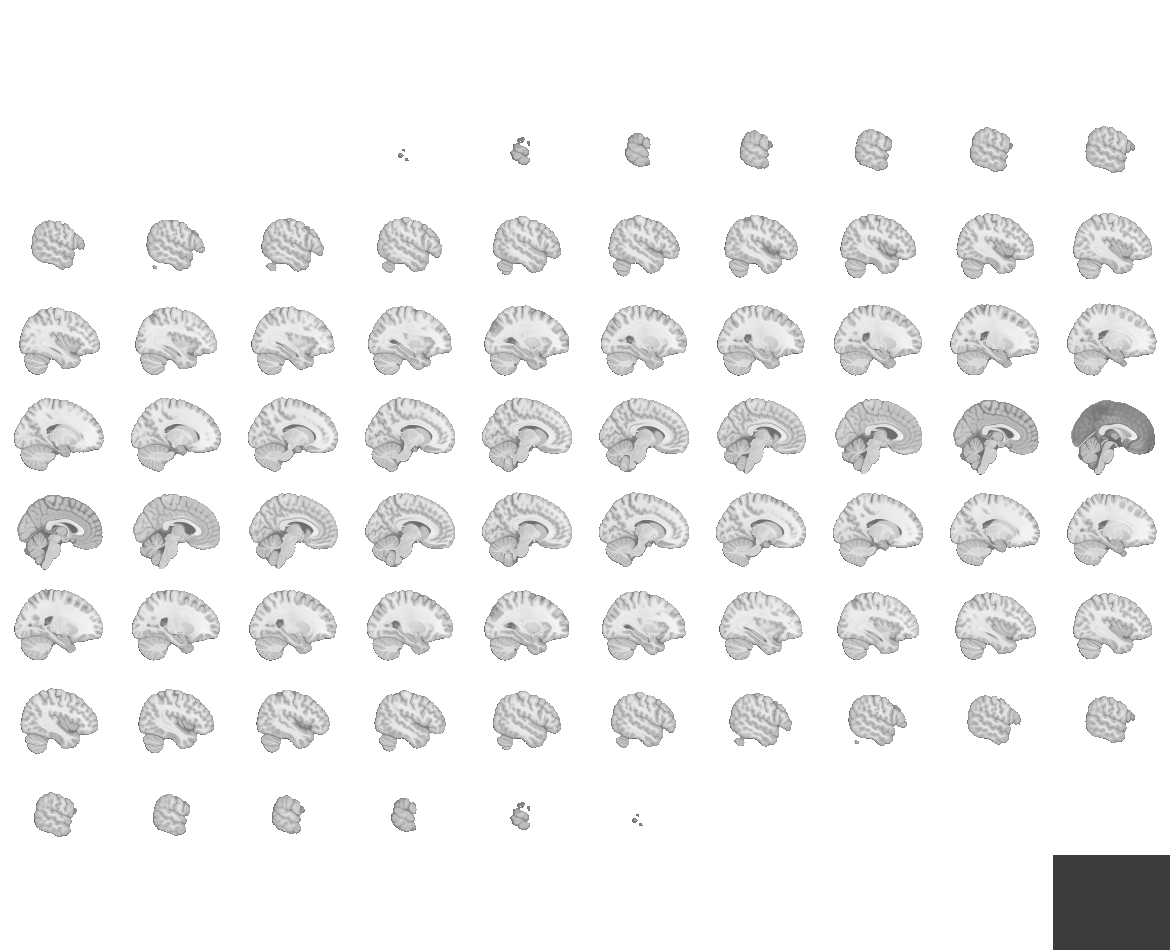
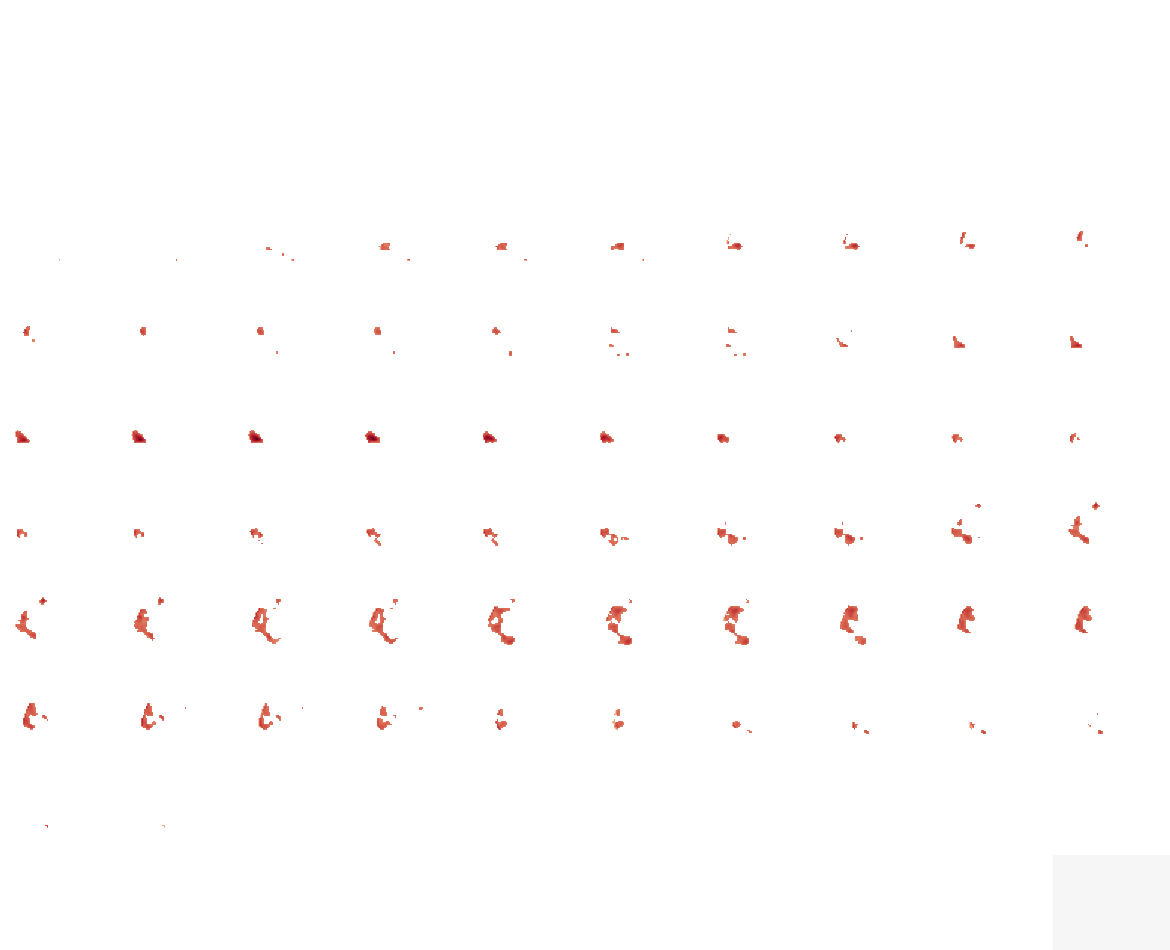

In [34]:
view = plotting.view_img(t_stat_sig_img_cluster, threshold=9, draw_cross=False, black_bg=False)
view

In [35]:
# nib.save(t_stat_sig_img_clsuter, os.path.join("./outputs/tBrainmap", 'tmap_beh60_p001_random.nii.gz'))
nib.save(t_stat_sig_img_cluster, os.path.join("./outputs/tBrainmap", 'tmap_emonet_p001.nii.gz'))


In [ ]:
t_stat_sig_img_cluster = nib.load(os.path.join("./outputs/tBrainmap", 'tmap_emonet_p001.nii.gz'))

c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\numpy\core\fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



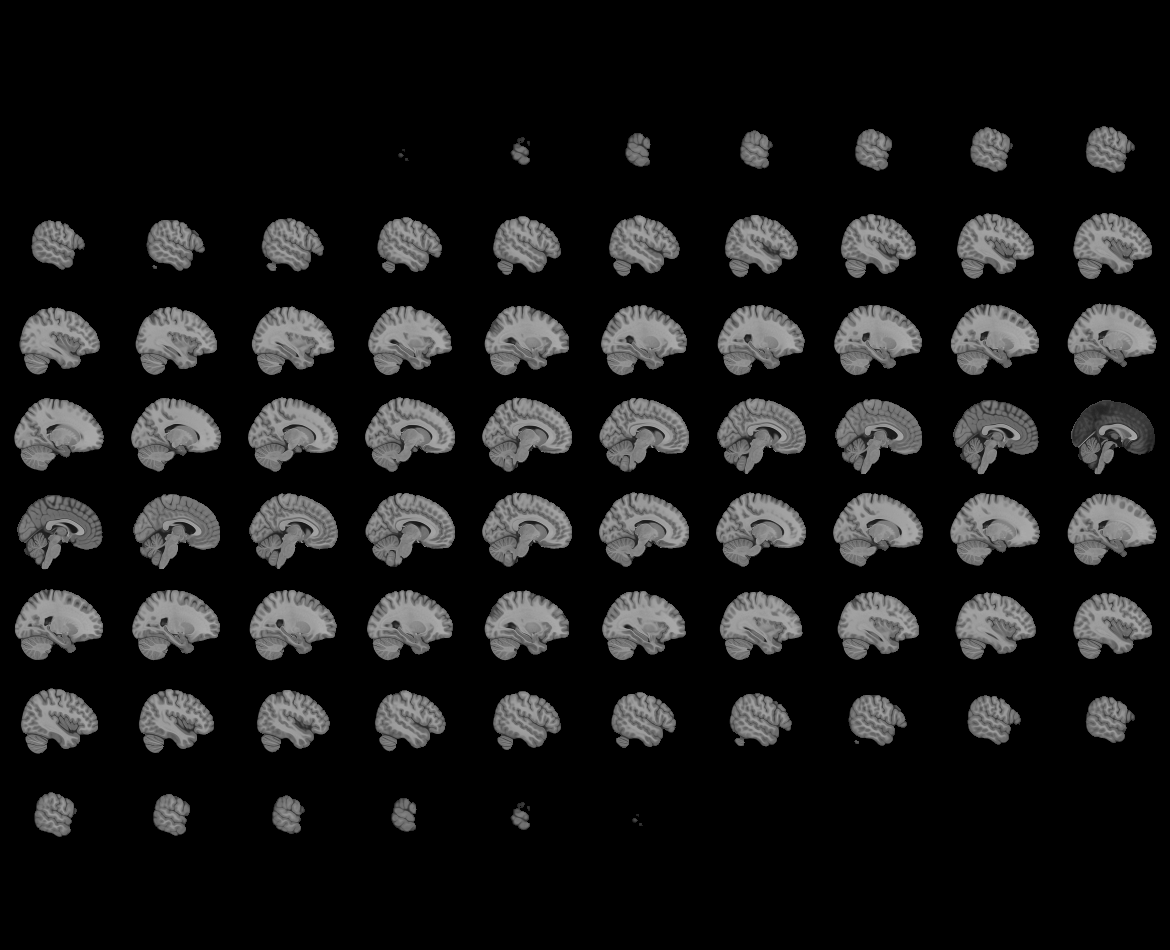
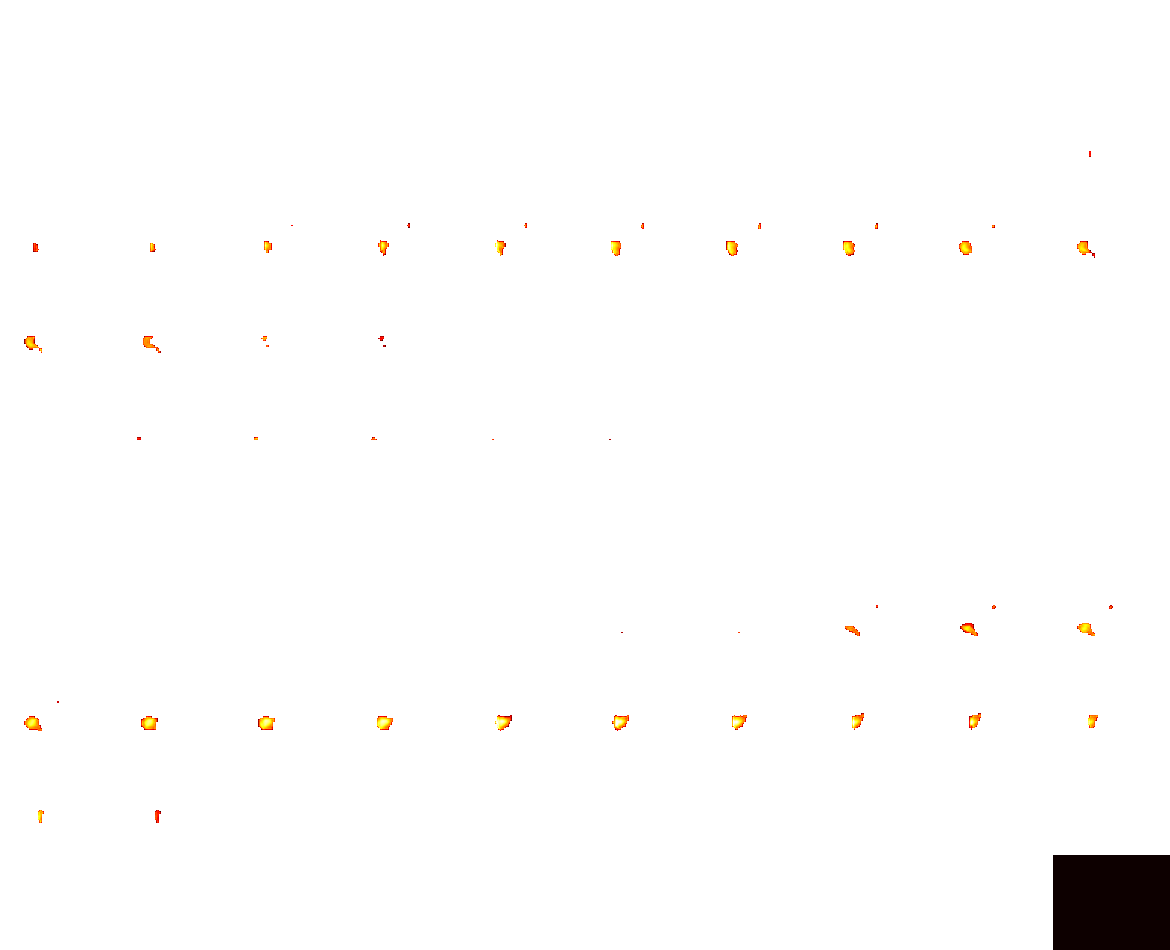

In [8]:
# 7. Visualize the significant voxel centers
view = plotting.view_img(t_stat_sig_img_cluster)
view